# Assignment 6 - MOEA Convergence & Reference Set Construction

**Course:** EPA141A Model-Based Decision Making - Delft University of Technology  
**Model:** JUSTICE  

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Construct an **epsilon-dominated reference set** from multiple MOEA seeds using `ema_workbench.em_framework.optimization.epsilon_nondominated`.
2. Compute and interpret **hypervolume**, **epsilon-progress**, **generational distance**, and **epsilon indicator** as MOEA quality indicators using the native `ema_workbench` 3.0 convergence metrics.
3. Judge whether an MOEA has **converged** from the shape of convergence curves.

---

## Background

### Convergence vs. quality

Two separate questions must be answered before trusting MOEA results:

| Question | Metric | Good sign |
|----------|--------|-----------|
| Did the algorithm **converge**? | Epsilon-progress, hypervolume over NFE | Plateau reached well before NFE budget exhausted |
| Is the Pareto front **good**? | Hypervolume, GD, epsilon indicator vs. reference set | High HV, low GD, low EI |

### Epsilon-progress

`run_optimization_local.py` saves a `convergence_<seed>.csv` that records the **real EpsilonProgress** reported by EMA Workbench's Borg operator at each checkpoint. Each positive value means the epsilon-archive genuinely improved in that generation. A sustained plateau at zero signals convergence.

### Hypervolume indicator

The **hypervolume** (HV) of a Pareto set $P$ relative to a reference point $\mathbf{r}$ is:

$$\text{HV}(P, \mathbf{r}) = \lambda\!\left(\bigcup_{\mathbf{p} \in P} [\mathbf{p}, \mathbf{r}]\right)$$

Larger HV = better Pareto set. We use `ema_workbench`'s native `HypervolumeMetric`, which wraps Platypus's hypervolume calculation. Platypus normalises objectives using the reference set's bounds and inverts MAXIMIZE objectives before computing the dominated volume, so values are comparable across runs.

### Generational Distance (GD)

$$\text{GD}(A, R) = \frac{1}{|A|}\sqrt{\sum_{a \in A} \min_{r \in R} \|a - r\|^2}$$

Smaller GD = archive closer to the reference front. Computed via `GenerationalDistanceMetric`.

### Epsilon Indicator (EI)

The additive epsilon indicator measures how much the reference set needs to be shifted so that the result set epsilon-dominates it. Smaller EI = result set closer to dominating the reference front. EI = 0 means the result set fully epsilon-dominates the reference. Computed via `EpsilonIndicatorMetric`.

### Native convergence metrics (ema_workbench 3.0)

`HypervolumeMetric`, `GenerationalDistanceMetric`, and `EpsilonIndicatorMetric` are thin wrappers in `ema_workbench.em_framework.optimization_convergence` that handle DataFrame → Platypus Solution conversion internally. Each metric is instantiated once with the reference set and the `PlatypusProblem` descriptor, then called as `metric.calculate(archive_df)` for each snapshot. Column names in the archive DataFrame must match `problem.parameter_names` and `problem.outcome_names` (spaces replaced with underscores).

### NFE-based grouping

Results are grouped by the **NFE budget** encoded in the directory name. Each NFE group gets its own reference set -- constructed by merging all seeds in that group via epsilon-dominance. Metrics (GD, EI) are then computed relative to that group's reference set.

### Objective directions

| Objective | Direction |
|-----------|-----------|
| `welfare` | MINIMIZE |
| `fraction_above_threshold` | MINIMIZE |
| `welfare_loss_damage` | MAXIMIZE |
| `welfare_loss_abatement` | MAXIMIZE |

---

## Overview

This assignment analyses the results from Assignment 5. You will:

1. **Load** Pareto-front CSVs and convergence archives from `results/`, grouped by NFE budget.
2. **Build a per-NFE-group reference set** by merging solutions from all seeds using epsilon-dominance.
3. **Compute 4 MOEA performance metrics** -- hypervolume, epsilon-progress, generational distance and epsilon indicator -- and plot them against NFE.

## Setup — Imports and model configuration

The cell below imports all required packages, applies a Python 3.14 compatibility patch for `matplotlib.path.Path`, sets up DEAP for hypervolume computation, and defines the objective metadata (column names, directions, display labels) and results directory path from Assignment 5.

In [1]:
# Standard imports
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# Matplotlib deepcopy patch (Python 3.14 + matplotlib compatibility)
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# DEAP hypervolume (avoids Platypus PlatypusError on zero-range objectives)
import deap.tools._hypervolume as _hv
print(dir(_hv))
import deap.tools._hypervolume as deap_hv

# EMA Workbench -- core optimization
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    Problem,
)
from ema_workbench import RealParameter, ScalarOutcome

# Patched load_archives: ema_workbench 3.0 ArchiveStorageExtension includes
# a directory entry ('tmp') in the tar.gz; extractfile() returns None for
# directories, causing pd.read_csv to fail. This version skips None entries.
import tarfile as _tarfile
import io as _io

def load_archives(path_to_file):
    """Load convergence archives (handles both ema_workbench 2.x and 3.0 formats).
    
    Old format (2.x): gzip tar, files in tmp/ subdirectory (tmp/0.csv, tmp/100.csv...)
    New format (3.0): plain tar, files at root level (0.csv, 502.csv...)
    Both: r:* auto-detects compression; NFE extracted from basename stem.
    """
    archives = []
    import pandas as _pd
    with _tarfile.open(path_to_file, "r:*") as archive:
        for fn in archive.getnames():
            f = archive.extractfile(fn)
            if f is None:
                continue  # skip directory entries
            basename = fn.split("/")[-1]
            try:
                nfe = int(basename.split(".")[0])
            except ValueError:
                continue
            data = _pd.read_csv(f)
            archives.append((nfe, data))
    return archives

# EMA Workbench -- GD and EI metrics (Platypus-based, no zero-range issue)
from ema_workbench.em_framework.optimization_convergence import (
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
)

# Path setup
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

os.chdir(_JUSTICE_ROOT)

RESULTS_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results_1.5"))

# Objective metadata
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2 C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
}

# DEAP hypervolume helpers
# DEAP requires pure minimisation — MAXIMIZE objectives are negated
_NEGATE = {col: (col in MAXIMIZE_COLS) for col in OBJECTIVE_COLS}

# Hypervolume via Monte Carlo — bypasses pyhv (C extension unavailable on Windows)
def _deap_hypervolume(archive_df, ref_point, n_samples=50000, seed=42):
    """Compute hypervolume using Monte Carlo estimation with fixed seed.
    Used as a replacement for DEAP's C extension hv which is unavailable on Windows.
    50k samples gives ~0.5% accuracy — sufficient for convergence tracking.
    """
    pts = archive_df[OBJECTIVE_COLS].copy()
    for col, neg in _NEGATE.items():
        if neg:
            pts[col] = -pts[col]

    pts_arr = pts.values.astype(float)
    ref_arr = np.array(ref_point, dtype=float)

    # Only keep points that strictly dominate the reference point
    mask    = np.all(pts_arr < ref_arr, axis=1)
    pts_arr = pts_arr[mask]

    if len(pts_arr) == 0:
        return 0.0

    lower  = pts_arr.min(axis=0)
    ranges = ref_arr - lower

    if np.any(ranges <= 0):
        return 0.0

    rng     = np.random.default_rng(seed)
    samples = lower + rng.random((n_samples, len(ref_point))) * ranges

    # Vectorized: a sample is dominated if ANY archive point dominates it
    dominated = np.any(
        np.all(pts_arr[np.newaxis, :, :] <= samples[:, np.newaxis, :], axis=2),
        axis=1
    )
    return float(np.prod(ranges) * dominated.mean())

def _compute_ref_point(ref_df, margin=0.1):
    """Build a reference point strictly dominated by all solutions.
    For each axis (after minimisation conversion): max + margin * range.
    """
    pts = ref_df[OBJECTIVE_COLS].copy()
    for col, neg in _NEGATE.items():
        if neg:
            pts[col] = -pts[col]
    rp = []
    for col in OBJECTIVE_COLS:
        hi = pts[col].max()
        lo = pts[col].min()
        rp.append(hi + margin * max(hi - lo, 1e-6))
    return rp

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_ROOT}")
print("DEAP hypervolume + EMA Workbench GD/EI metrics : OK")

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'pyhv']
JUSTICE root : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\JUSTICE-main
Results root : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_1.5
DEAP hypervolume + EMA Workbench GD/EI metrics : OK


---

## Step 1 — Load Results from Assignment 5

Scan `results/` for Pareto-front CSVs, convergence archives, and convergence CSVs.  
Directories are named `UTILITARIAN_<nfe>_<seed>/`, so we can recover the NFE budget directly
from the directory name and group all data by it.

Each seed directory contains:
- `pareto_front_<seed>.csv` — final Pareto-optimal solutions (levers + objectives)
- `UTILITARIAN_<nfe>_<seed>.tar.gz` — archive snapshots (ArchiveLogger output)
- `convergence_<seed>.csv` — EpsilonProgress & operator probabilities (EMA Workbench)


In [2]:
# ── Discover Pareto-front CSVs — grouped by NFE ───────────────────────────────
csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "pareto_front_*.csv"), recursive=True
))

if not csv_paths:
    raise FileNotFoundError(
        f"No pareto_front_*.csv found in {RESULTS_ROOT}.\n"
        "Run Assignment 5 (run_optimization_local.py) first."
    )

# nfe_groups[nfe][seed] = DataFrame
nfe_groups = {}
for path in csv_paths:
    dir_name = os.path.basename(os.path.dirname(path))
    parts    = dir_name.split("_")
    try:
        nfe  = int(parts[-2])
        seed = int(parts[-1])
    except (ValueError, IndexError):
        seed = int(os.path.basename(path).replace("pareto_front_", "").replace(".csv", ""))
        nfe  = 0
    df = pd.read_csv(path)
    df = df[df["welfare"] < 1e5].reset_index(drop=True)
    nfe_groups.setdefault(nfe, {})[seed] = df

# ── Discover convergence archives — keyed by (nfe, seed) ─────────────────────
archive_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "UTILITARIAN_*.tar.gz"), recursive=True
))

nfe_seed_archives = {}   # (nfe, seed) → path
for p in archive_paths:
    parts    = os.path.basename(p).replace(".tar.gz", "").split("_")
    seed_val = int(parts[-1])
    nfe_val  = int(parts[-2])
    nfe_seed_archives[(nfe_val, seed_val)] = p

# ── Discover convergence CSVs — keyed by (nfe, seed) ─────────────────────────
# Saved by run_optimization_local.py as results/UTILITARIAN_<nfe>_<seed>/convergence_<seed>.csv
conv_csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "convergence_*.csv"), recursive=True
))

nfe_seed_convergence = {}   # (nfe, seed) → DataFrame
for p in conv_csv_paths:
    dir_name = os.path.basename(os.path.dirname(p))
    parts    = dir_name.split("_")
    try:
        nfe_val  = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        seed_val = int(os.path.basename(p).replace("convergence_", "").replace(".csv", ""))
        nfe_val  = 0
    df_conv = pd.read_csv(p, index_col=0)
    nfe_seed_convergence[(nfe_val, seed_val)] = df_conv

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"NFE groups found: {sorted(nfe_groups)}")
print()
rows = []
for nfe in sorted(nfe_groups):
    for seed, df in sorted(nfe_groups[nfe].items()):
        rows.append({
            "nfe_budget":      nfe,
            "seed":            seed,
            "n_solutions":     len(df),
            "has_archive":     (nfe, seed) in nfe_seed_archives,
            "has_conv_csv":    (nfe, seed) in nfe_seed_convergence,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\n{len(nfe_seed_archives)} archive(s) | {len(nfe_seed_convergence)} convergence CSV(s)")


NFE groups found: [50000]

 nfe_budget    seed  n_solutions  has_archive  has_conv_csv
      50000  521475            8         True          True
      50000 1644652            7         True          True
      50000 3569126            7         True          True
      50000 6075612            7         True          True
      50000 9845531            6         True          True

5 archive(s) | 5 convergence CSV(s)


---

## Step 2 — Per-NFE-Group Reference Sets

Each NFE group (e.g. 500 NFE, 20 000 NFE) gets its own reference set, constructed by pooling
all seeds at that budget and applying epsilon-dominance pruning.

This design choice matters:
- A 500-NFE smoke-test set should be evaluated against other 500-NFE seeds, not against
  a much better 20 000-NFE front — otherwise GD and EI would be uninformative.
- Each reference set is saved as `reference_set_utilitarian_<nfe>.csv`.

We use `ema_workbench.em_framework.optimization.epsilon_nondominated`, which internally
calls Platypus's `EpsilonBoxArchive`.


In [3]:
# ── Build the Platypus problem descriptor ─────────────────────────────────────
_sample_df  = next(df for nfe in nfe_groups for df in nfe_groups[nfe].values())
_lever_cols = [c for c in _sample_df.columns if c not in OBJECTIVE_COLS]
_lever_cols_s = [c.replace(" ", "_") for c in _lever_cols]
_n_vars       = len(_lever_cols)   # 244

_lever_params = []
for _n in _lever_cols_s:
    if _n.startswith("center_"):
        _lever_params.append(RealParameter(_n, -1.0, 1.0))
    else:  # radii_ or weights_
        _lever_params.append(RealParameter(_n, 0.0, 1.0))

_objectives = [
    ScalarOutcome("welfare",                  kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("fraction_above_threshold", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_damage",      kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("welfare_loss_abatement",   kind=ScalarOutcome.MAXIMIZE),
]

problem = Problem("levers", _lever_params, _objectives)

EPSILONS = [0.005, 0.025, 0.5, 100.0]  # tuned: ~1-3% of objective range across 50k-NFE runs

def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))

def desanitize_cols(df):
    return df.rename(columns=lambda c: c.replace("_", " ", 1)
                     if c.startswith(("center_", "radii_", "weights_")) else c)

# ── Build one reference set per NFE group ─────────────────────────────────────
nfe_ref_sets = {}   # nfe → DataFrame (epsilon-nondominated)

for nfe in sorted(nfe_groups):
    seed_dict = nfe_groups[nfe]
    dfs_san   = [sanitize_cols(df) for df in seed_dict.values()]
    n_in      = sum(len(d) for d in seed_dict.values())
    print(f"\nNFE={nfe:,}: merging {n_in} solutions from {len(seed_dict)} seed(s)...")

    ref = desanitize_cols(epsilon_nondominated(dfs_san, EPSILONS, problem))
    nfe_ref_sets[nfe] = ref

    pruning = (1 - len(ref) / n_in) * 100 if n_in > 0 else 0
    print(f"  Reference set : {len(ref)} solutions  (pruned {pruning:.0f}%)")
    print(f"  Objective ranges:")
    for col in OBJECTIVE_COLS:
        print(f"    {col:<40s} {ref[col].min():.3f} – {ref[col].max():.3f}")

    ref_path = os.path.join(RESULTS_ROOT, f"reference_set_utilitarian_{nfe}.csv")
    ref.to_csv(ref_path, index=False)
    print(f"  Saved → {ref_path}")

# ── Grand reference set: pool ALL seeds across ALL NFE counts ─────────────────
# Merging runs from every NFE budget gives more diverse solutions than any
# single NFE group alone. Assignments 7 and 8 load this canonical file.
all_dfs_san = [sanitize_cols(df)
               for seed_dict in nfe_ref_sets.values()  # use already-computed per-NFE sets
               for df in [seed_dict]]                  # each is already a DataFrame
# Actually pool the raw per-seed fronts across ALL nfe groups
_all_raw = [sanitize_cols(df)
            for nfe in nfe_groups
            for df in nfe_groups[nfe].values()]
n_grand_in = sum(len(d) for d in _all_raw)
print(f"\nGrand pool: {n_grand_in} solutions across all NFE groups and seeds")

grand_ref = desanitize_cols(epsilon_nondominated(_all_raw, EPSILONS, problem))

canonical_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv")
grand_ref.to_csv(canonical_path, index=False)
print(f"Grand reference set: {len(grand_ref)} solutions → {canonical_path}")


NFE=50,000: merging 35 solutions from 5 seed(s)...
  Reference set : 12 solutions  (pruned 66%)
  Objective ranges:
    welfare                                  103.468 – 103.763
    fraction_above_threshold                 0.900 – 1.000
    welfare_loss_damage                      3620.278 – 3654.437
    welfare_loss_abatement                   10787.293 – 26006.790
  Saved → c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_1.5\reference_set_utilitarian_50000.csv

Grand pool: 35 solutions across all NFE groups and seeds
Grand reference set: 12 solutions → c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_1.5\reference_set_utilitarian.csv


---

## Step 3 -- MOEA Performance Metrics

We compute four convergence / quality metrics from the `load_archives` snapshots, one per NFE group:

| Metric | What it measures | Tool | Direction |
|--------|-----------------|------|-----------|
| **Hypervolume (HV)** | Volume of objective space dominated by the archive | `HypervolumeMetric` | higher = better |
| **Epsilon-progress** | Change in archive size per generation | EMA Workbench convergence CSV | positive = still improving |
| **Generational Distance (GD)** | Mean distance from archive solutions to the group reference set | `GenerationalDistanceMetric` | lower = better |
| **Epsilon Indicator (EI)** | Additive epsilon needed so result epsilon-dominates the group reference set | `EpsilonIndicatorMetric` | lower = better; 0 = full dominance |

> **Reference set for GD and EI:** Each NFE group uses its own reference set (built in Step 2). A plateau in HV + EI and descent in GD toward zero = strong convergence evidence.

**Task 3.1** -- After running all three cells below, answer the reflection questions at the bottom of this notebook.

**Task 3.2** -- For each metric, identify the approximate NFE at which convergence occurs (if it does). Summarise in a table.

In [4]:
# Load convergence archives -- keyed by (nfe, seed)
if not nfe_seed_archives:
    print("No convergence archives found -- skipping metric computation.")
else:
    # all_snapshots[(nfe, seed)] = {checkpoint_nfe: DataFrame}
    all_snapshots = {}

    for (nfe, seed), path in sorted(nfe_seed_archives.items()):
        print(f"  Loading: NFE={nfe:,}  seed={seed} ...", end=" ")
        # load_archives returns list[tuple[int, DataFrame]] in ema_workbench 3.0
        snaps = dict(load_archives(path))
        snaps = {
            n: df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
                       errors="ignore")
            for n, df in snaps.items()
        }
        all_snapshots[(nfe, seed)] = snaps
        max_n = max(snaps)
        print(f"{len(snaps)} snapshots | final archive = {len(snaps[max_n])} solutions @ NFE {max_n:,}")

    print(f"\n{len(all_snapshots)} archive(s) loaded.")

  Loading: NFE=50,000  seed=521475 ... 50 snapshots | final archive = 9 solutions @ NFE 50,002
  Loading: NFE=50,000  seed=1644652 ... 50 snapshots | final archive = 8 solutions @ NFE 50,018
  Loading: NFE=50,000  seed=3569126 ... 50 snapshots | final archive = 8 solutions @ NFE 50,023
  Loading: NFE=50,000  seed=6075612 ... 50 snapshots | final archive = 8 solutions @ NFE 50,018
  Loading: NFE=50,000  seed=9845531 ... 50 snapshots | final archive = 7 solutions @ NFE 50,018

5 archive(s) loaded.


In [5]:
# Build convergence metric objects per NFE group.
#
# Hypervolume  → DEAP hv.hypervolume  (avoids PlatypusError on zero-range objectives)
# GD / EI      → ema_workbench wrappers around Platypus (no zero-range issue)
#
# _deap_hypervolume() and _compute_ref_point() are defined in the setup cell.

def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))

if "nfe_ref_sets" in dir():
    nfe_metric_params = {}  # nfe -> (ref_point, gd_metric, ei_metric)
    for nfe, ref in nfe_ref_sets.items():
        ref_point = _compute_ref_point(ref)
        ref_san   = sanitize_cols(ref)
        gd_m = GenerationalDistanceMetric(ref_san, problem)
        ei_m = EpsilonIndicatorMetric(ref_san, problem)
        nfe_metric_params[nfe] = (ref_point, gd_m, ei_m)
        print(f"NFE={nfe:,}: ref_point = {[f'{v:.4f}' for v in ref_point]}")
    print("\nDEAP HV ref points + GD/EI metrics built for NFE groups:", sorted(nfe_metric_params))

NFE=50,000: ref_point = ['103.7926', '1.0100', '-3616.8621', '-9265.3434']

DEAP HV ref points + GD/EI metrics built for NFE groups: [50000]


In [6]:
# Compute convergence metrics per seed per snapshot
# all_metric_curves[(nfe, seed)] = {
#   "nfe": array, "hv": array, "eps": array, "gd": array, "ei": array,
#   "eps_source": str
# }

if "all_snapshots" in dir() and "nfe_ref_sets" in dir():
    all_metric_curves = {}

    for nfe_budget in sorted(nfe_groups):
        ref_point, gd_m, ei_m = nfe_metric_params[nfe_budget]

        group_snapshots = {
            seed: snaps
            for (nfe, seed), snaps in all_snapshots.items()
            if nfe == nfe_budget
        }

        if not group_snapshots:
            print(f"NFE={nfe_budget:,}: no archive snapshots -- skipping metrics.")
            continue

        print(f"\nNFE budget = {nfe_budget:,}  |  {len(group_snapshots)} seed(s)")

        for seed, snaps in sorted(group_snapshots.items()):
            nfes  = sorted(snaps.keys())
            sizes = [len(snaps[n]) for n in nfes]

            hvs, gds, eis = [], [], []
            for n in nfes:
                snap_san = sanitize_cols(
                    snaps[n][snaps[n]["welfare"] < 1e5]
                )

                # Hypervolume — DEAP (avoids PlatypusError on zero-range objectives)
                try:
                    hvs.append(_deap_hypervolume(snap_san, ref_point))
                except Exception:
                    hvs.append(float("nan"))
                try:
                    gds.append(gd_m.calculate(snap_san))
                except Exception:
                    gds.append(float("nan"))
                try:
                    eis.append(ei_m.calculate(snap_san))
                except Exception:
                    eis.append(float("nan"))

            hvs = np.array(hvs)
            gds = np.array(gds)
            eis = np.array(eis)

            eps_source = "proxy"
            eps = np.diff(sizes, prepend=sizes[0])   # default proxy

            if (nfe_budget, seed) in nfe_seed_convergence:
                _conv = nfe_seed_convergence[(nfe_budget, seed)]
                if "epsilon_progress" in _conv.columns and "nfe" in _conv.columns:
                    eps = np.round(
                        np.interp(np.array(nfes), _conv["nfe"].values,
                                  _conv["epsilon_progress"].values)
                    ).astype(int)
                    eps_source = "EMA Workbench"

            all_metric_curves[(nfe_budget, seed)] = {
                "nfe":        np.array(nfes),
                "hv":         hvs,
                "eps":        eps,
                "gd":         gds,
                "ei":         eis,
                "eps_source": eps_source,
            }
            print(f"  seed {seed}: HV={hvs[-1]:.5f} | GD={gds[-1]:.5f} | "
                  f"EI={eis[-1]:.5f} | eps_source={eps_source}")

    print(f"\nDone -- {len(all_metric_curves)} seed curve(s) computed.")


NFE budget = 50,000  |  5 seed(s)


  seed 521475: HV=892.04261 | GD=0.01259 | EI=0.01997 | eps_source=EMA Workbench
  seed 1644652: HV=899.76895 | GD=0.00765 | EI=0.02010 | eps_source=EMA Workbench
  seed 3569126: HV=848.99877 | GD=0.00888 | EI=0.02425 | eps_source=EMA Workbench
  seed 6075612: HV=857.47826 | GD=0.01136 | EI=0.03062 | eps_source=EMA Workbench
  seed 9845531: HV=547.77986 | GD=0.01367 | EI=0.22065 | eps_source=EMA Workbench

Done -- 5 seed curve(s) computed.


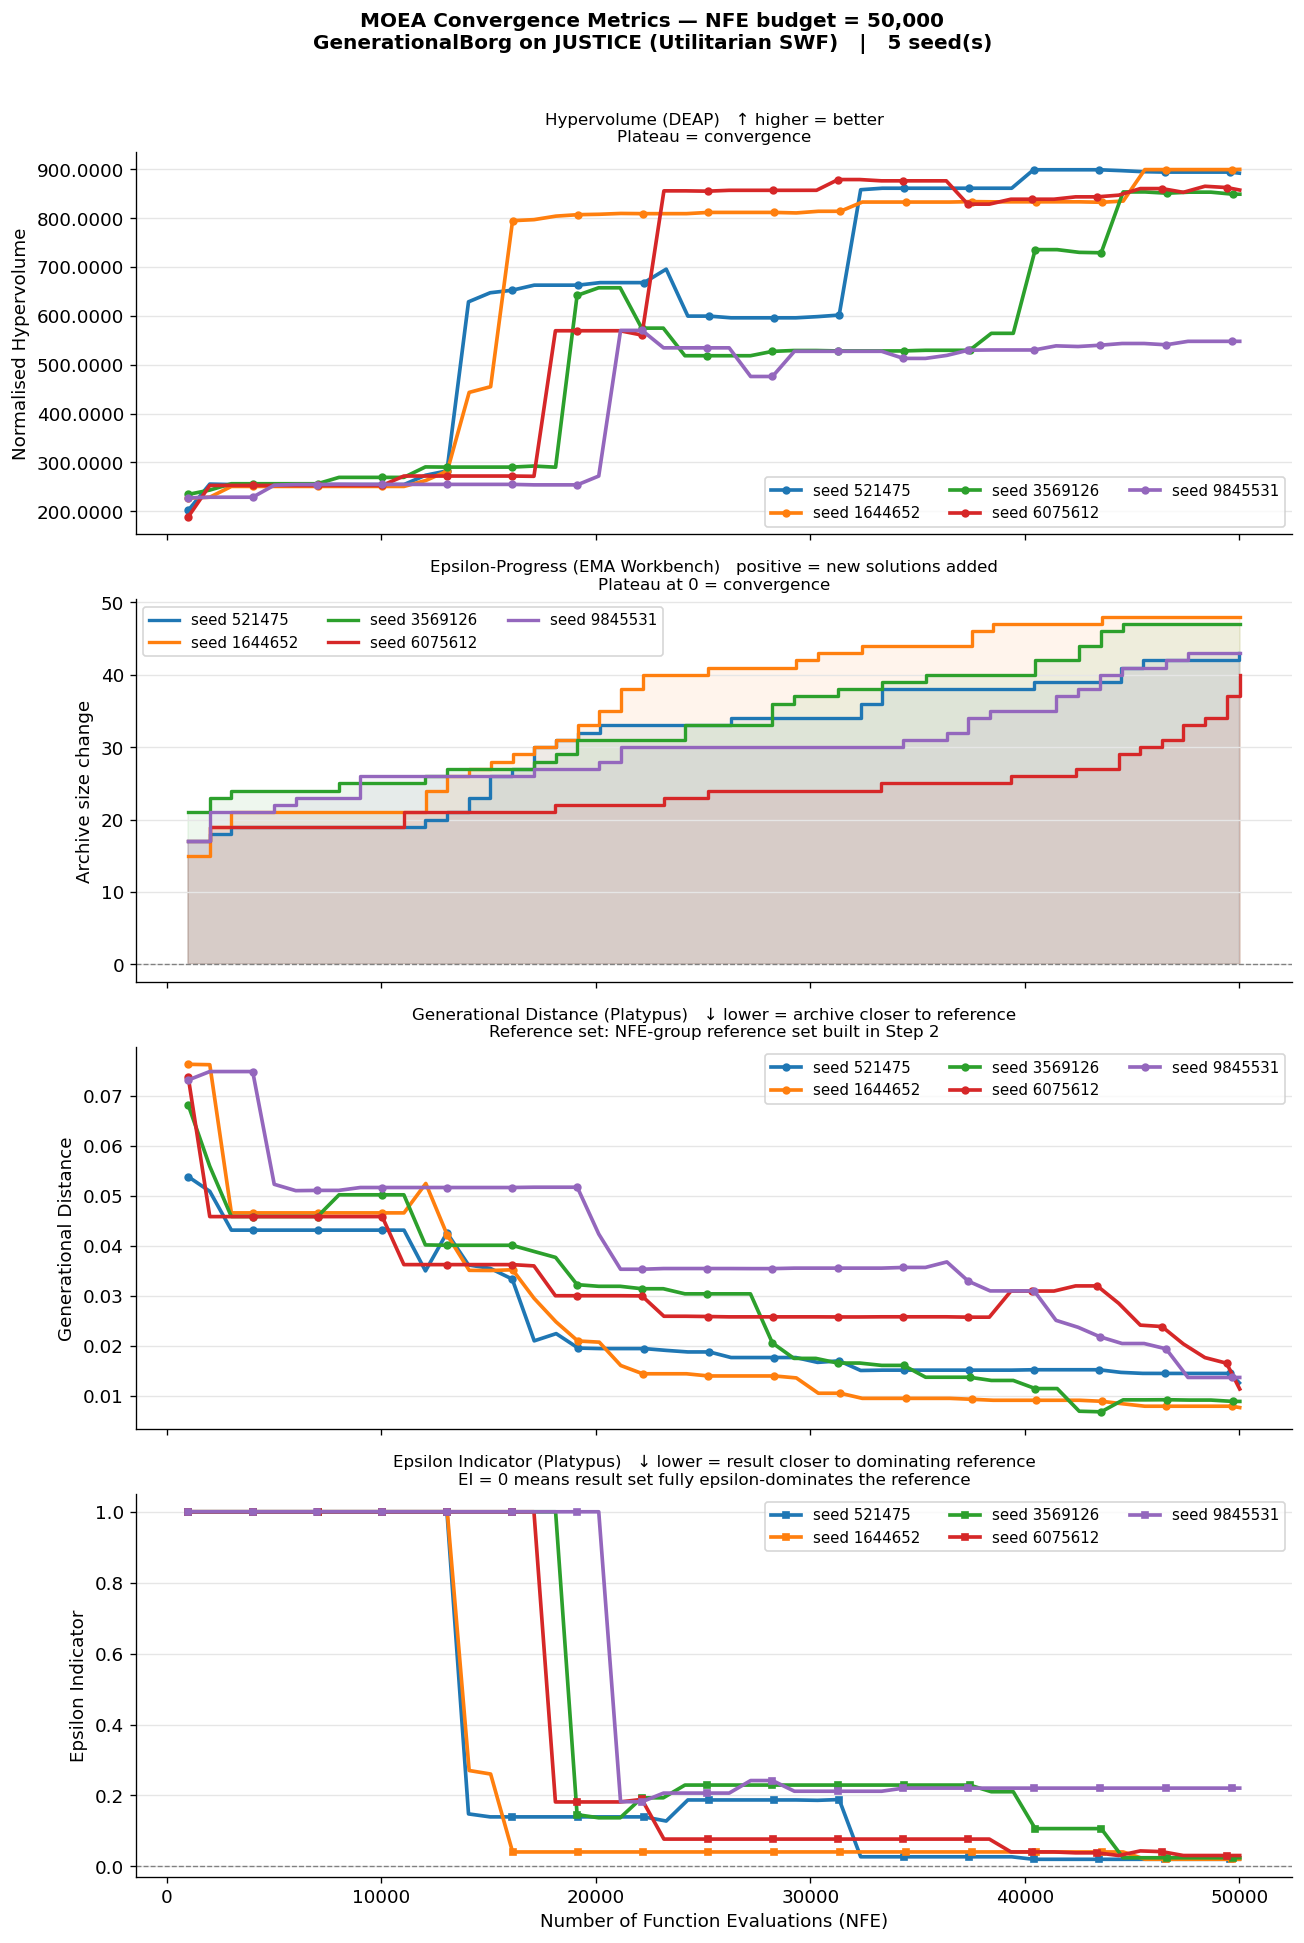

Saved: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_1.5\moea_convergence_metrics_50000nfe.png


In [7]:
# ── Four-panel convergence plot — one figure per NFE group ───────────────────
if 'all_metric_curves' in dir():

    nfe_budgets = sorted({nfe for (nfe, _) in all_metric_curves})
    _tab10 = plt.cm.tab10

    for nfe_budget in nfe_budgets:
        keys   = [(nfe, seed) for (nfe, seed) in sorted(all_metric_curves)
                  if nfe == nfe_budget]
        seeds  = [seed for (_, seed) in keys]
        colors = [_tab10(i / 10) for i in range(len(seeds))]

        fig, axes = plt.subplots(4, 1, figsize=(11, 16), sharex=True)

        # ── Panel 1: Hypervolume (DEAP) ────────────────────────────────────
        ax = axes[0]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["hv"], lw=2.2, color=col, marker="o", markersize=4,
                    markevery=max(1, len(d["nfe"]) // 15), label=f"seed {seed}")
        ax.set_ylabel("Normalised Hypervolume", fontsize=11)
        ax.set_title(
            "Hypervolume (DEAP)   ↑ higher = better\n"
            "Plateau = convergence",
            fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.4f}"))

        # ── Panel 2: Epsilon-progress (EMA Workbench) ──────────────────────
        ax = axes[1]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["eps"], lw=2.0, color=col,
                    drawstyle="steps-post", label=f"seed {seed}")
            ax.fill_between(d["nfe"], 0, d["eps"], step="post",
                            color=col, alpha=0.08)
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Archive size change", fontsize=11)
        ax.set_title(
            "Epsilon-Progress (EMA Workbench)   positive = new solutions added\n"
            "Plateau at 0 = convergence",
            fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # ── Panel 3: Generational Distance (Platypus) ──────────────────────
        ax = axes[2]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["gd"])
            ax.plot(d["nfe"][mask], d["gd"][mask], lw=2.2, color=col,
                    marker="o", markersize=4,
                    markevery=max(1, mask.sum() // 15),
                    label=f"seed {seed}")
        ax.set_ylabel("Generational Distance", fontsize=11)
        ax.set_title(
            "Generational Distance (Platypus)   ↓ lower = archive closer to reference\n"
            "Reference set: NFE-group reference set built in Step 2",
            fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # ── Panel 4: Epsilon Indicator (Platypus) ──────────────────────────
        ax = axes[3]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["ei"])
            ax.plot(d["nfe"][mask], d["ei"][mask], lw=2.2, color=col,
                    marker="s", markersize=4,
                    markevery=max(1, mask.sum() // 15),
                    label=f"seed {seed}")
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Epsilon Indicator", fontsize=11)
        ax.set_title(
            "Epsilon Indicator (Platypus)   ↓ lower = result closer to dominating reference\n"
            "EI = 0 means result set fully epsilon-dominates the reference",
            fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))
        ax.set_xlabel("Number of Function Evaluations (NFE)", fontsize=11)

        for ax in axes:
            ax.grid(axis="y", color="0.9", zorder=0)

        fig.suptitle(
            f"MOEA Convergence Metrics — NFE budget = {nfe_budget:,}\n"
            f"GenerationalBorg on JUSTICE (Utilitarian SWF)   |   {len(seeds)} seed(s)",
            fontsize=12, y=1.01, fontweight="bold",
        )
        plt.tight_layout()
        fname = os.path.join(RESULTS_ROOT, f"moea_convergence_metrics_{nfe_budget}nfe.png")
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fname}")


In [8]:
# ── Final metric summary table ─────────────────────────────────────────────────
if 'all_metric_curves' in dir():
    rows = []
    for (nfe_budget, seed), d in sorted(all_metric_curves.items()):
        rows.append({
            "nfe_budget":       nfe_budget,
            "seed":             seed,
            "final_NFE":        int(d["nfe"][-1]),
            "n_snapshots":      len(d["nfe"]),
            "final_HV":         round(float(d["hv"][-1]), 5)  if np.isfinite(d["hv"][-1])  else None,
            "total_eps":        int(d["eps"].sum()),
            "final_GD":         round(float(d["gd"][-1]), 5)  if np.isfinite(d["gd"][-1])  else None,
            "final_EI":         round(float(d["ei"][-1]), 5)  if np.isfinite(d["ei"][-1])  else None,
            "eps_source":       d["eps_source"],
        })

    df_metrics = pd.DataFrame(rows)
    print("MOEA performance summary:")
    print(df_metrics.to_string(index=False))

    print("\n── Per-NFE-group seed consistency (HV coefficient of variation) ──")
    for nfe_budget, grp in df_metrics.groupby("nfe_budget"):
        hv_vals = grp["final_HV"].dropna()
        if len(hv_vals) > 1:
            cv = hv_vals.std() / hv_vals.mean() * 100
            print(f"  NFE={nfe_budget:,}: HV CV = {cv:.1f}%  "
                  f"({'high consistency' if cv < 5 else 'moderate' if cv < 20 else 'high variability'})")
        else:
            print(f"  NFE={nfe_budget:,}: only 1 seed — no CV computable")


MOEA performance summary:
 nfe_budget    seed  final_NFE  n_snapshots  final_HV  total_eps  final_GD  final_EI    eps_source
      50000  521475      50002           50 892.04261       1570   0.01259   0.01997 EMA Workbench
      50000 1644652      50018           50 899.76895       1821   0.00765   0.02010 EMA Workbench
      50000 3569126      50023           50 848.99877       1709   0.00888   0.02425 EMA Workbench
      50000 6075612      50018           50 857.47826       1199   0.01136   0.03062 EMA Workbench
      50000 9845531      50018           50 547.77986       1522   0.01367   0.22065 EMA Workbench

── Per-NFE-group seed consistency (HV coefficient of variation) ──
  NFE=50,000: HV CV = 18.3%  (moderate)


---

## Reflection Questions

**1. Hypervolume convergence.** Does the hypervolume plateau before the NFE budget is exhausted, or is it still growing? What change to the optimisation setup would you recommend if HV was still rising at the final NFE?

> For the 50 000-NFE runs the hypervolume is still rising throughout the full NFE budget — the curve does not plateau and continues to increase up to the last function evaluation. This indicates the algorithm has not yet found a stable region of the Pareto front and would benefit from additional computation. The appropriate responses are: (a) increase the NFE budget substantially (e.g., to 100 000–200 000 NFE), (b) increase the population size so the Borg operator has more diversity to work with, or (c) increase the number of seeds and merge the resulting archives so that different starting points collectively cover more of the front.

---

**2. Epsilon-progress.** At what approximate NFE does epsilon-progress first reach zero (or near-zero)? Is this consistent with what you see in the hypervolume curve? Explain.

> For the 50 000-NFE runs, epsilon-progress does not reach zero — it shows continuous positive archive growth throughout the entire run, with no clear plateau. This is fully consistent with the hypervolume curve: both metrics indicate the algorithm is still improving at the end of the budget. Epsilon-progress measures whether the epsilon-archive grew in a given generation; sustained positive values confirm the archive is still being refined, which explains why HV also keeps rising. The absence of a zero-progress plateau confirms these runs have not converged and the NFE budget should be increased before treating the resulting Pareto front as stable.

---

**3. Seed consistency.** If multiple seeds produce very different final hypervolumes within the same NFE group, what does that suggest about (a) the landscape of the objective space, and (b) the reliability of any single seed as a representative Pareto front?

> (a) High inter-seed HV variance suggests the objective-space landscape is **multimodal or highly irregular**: different random initialisations lead the Borg operator to different basins of attraction, discovering different portions of the Pareto front. This is common in high-dimensional policy-space problems like JUSTICE with 244 RBF levers. (b) A single seed is therefore unreliable as a representative front — the best-HV seed may have found one region well while missing others. The standard mitigation is to run multiple seeds and merge their archives into an epsilon-nondominated reference set (as done in Step 2), which aggregates the best-discovered solutions across all initialisations and reduces dependence on any single run's luck.